# 🧠 Physics-Informed Neural Networks — Hands-On Tutorial

**AI for Civil Engineering — MTech Programme**

---

### Today's roadmap (90 min):

| # | Module | PDE | Your Department | Time |
|---|--------|-----|-----------------|------|
| 1 | **Darcy Seepage** | ∇²h = 0 | Geotech · Water Resources · Hydraulics | 20 min |
| 2 | **Euler-Bernoulli Beam** | EI · d⁴v/dx⁴ = q | Structural | 20 min |
| 3 | **Pollutant Transport** | ∂c/∂t + u·∂c/∂x = D·∂²c/∂x² | Transport · Environmental | 20 min |
| 4 | **Burgers' Equation** | ∂u/∂t + u·∂u/∂x = ν·∂²u/∂x² | Hydraulics (= 1D Navier-Stokes!) | 15 min |
| 5 | **Wrap-up & Your Ideas** | — | All | 15 min |

### The PINN recipe (same for EVERY problem):

```
1. Write down your PDE           →  "the physics you already know"
2. Define boundary/initial conds  →  "your engineering constraints"
3. Let DeepXDE train a neural net →  "minimize PDE residual + BC loss"
4. Visualize & validate           →  "compare with analytical / FEM"
```

> 📌 **Run each cell in order.** GPU recommended (Runtime → Change runtime type → T4 GPU).


## ⚙️ Setup — Install & Import (run once)


In [ ]:
# ── Install DeepXDE ──────────────────────────────────────────────────
!pip install deepxde -q

import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DeepXDE version: {dde.__version__}")
print(f"Backend: {dde.backend.backend_name}")
print(f"Device:  {device}")
print("✅ Setup complete!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 10.2 MB/s eta 0:00:00


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


DeepXDE version: 1.15.0
Backend: pytorch
Device:  cuda
✅ Setup complete!


---

# 🌊 Module 1 — Darcy Seepage (Laplace Equation)

**Departments**: Geotechnical · Water Resources · Hydraulics

### The physics you already know:

**Darcy's Law:** $\mathbf{q} = -K \nabla h$

**Continuity + constant K** gives the **Laplace equation**:

$$\nabla^2 h = \frac{\partial^2 h}{\partial x^2} + \frac{\partial^2 h}{\partial y^2} = 0$$

### Our problem — seepage under a dam:

| Boundary | Condition | Meaning |
|----------|-----------|---------|
| Left (x=0) | h = 10 m | Upstream reservoir |
| Right (x=Lₓ) | h = 2 m | Downstream tail water |
| Top & Bottom | ∂h/∂n = 0 | Impervious boundaries |

> 🏗️ **Real world**: Dam foundation seepage, sheet pile cutoff analysis, levee underseepage


### 1.1 Define parameters & analytical solution


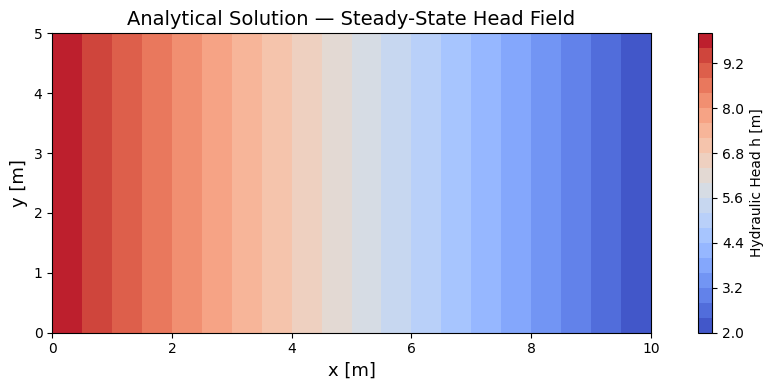

Head drop: 10.0 → 2.0 m over 10.0 m
Hydraulic gradient: i = 0.80


In [ ]:
# ── Seepage parameters ───────────────────────────────────────────────
Lx = 10.0     # Domain length [m]
Ly = 5.0      # Domain height [m]
H1 = 10.0     # Upstream head [m]
H2 = 2.0      # Downstream head [m]

# Exact: linear head drop for 1D confined flow
def analytical_seepage(x):
    return H1 + (H2 - H1) * x[:, 0:1] / Lx

# Visualize the exact solution
fig, ax = plt.subplots(figsize=(10, 4))
x_plot = np.linspace(0, Lx, 100)
y_plot = np.linspace(0, Ly, 50)
X, Y = np.meshgrid(x_plot, y_plot)
H_exact = H1 + (H2 - H1) * X / Lx

cs = ax.contourf(X, Y, H_exact, levels=20, cmap='coolwarm')
plt.colorbar(cs, label='Hydraulic Head h [m]')
ax.set_xlabel('x [m]', fontsize=13)
ax.set_ylabel('y [m]', fontsize=13)
ax.set_title('Analytical Solution — Steady-State Head Field', fontsize=14)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"Head drop: {H1} → {H2} m over {Lx} m")
print(f"Hydraulic gradient: i = {(H1-H2)/Lx:.2f}")


### 1.2 Define PDE & boundary conditions in DeepXDE

> 🔑 **Key**: We compute ∂²h/∂x² and ∂²h/∂y² using **automatic differentiation** — exact derivatives through the neural network!


In [ ]:
# ── PDE residual: Laplace d²h/dx² + d²h/dy² = 0 ────────────────────
def laplace_pde(x, h):
    dh_xx = dde.grad.hessian(h, x, i=0, j=0)
    dh_yy = dde.grad.hessian(h, x, i=1, j=1)
    return dh_xx + dh_yy

# ── Geometry & boundaries ────────────────────────────────────────────
geom_seep = dde.geometry.Rectangle([0, 0], [Lx, Ly])

def bnd_left(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0)
def bnd_right(x, on_boundary):
    return on_boundary and np.isclose(x[0], Lx)
def bnd_top(x, on_boundary):
    return on_boundary and np.isclose(x[1], Ly)
def bnd_bottom(x, on_boundary):
    return on_boundary and np.isclose(x[1], 0)

bc_L = dde.icbc.DirichletBC(geom_seep, lambda x: H1 * np.ones_like(x[:, 0:1]), bnd_left)
bc_R = dde.icbc.DirichletBC(geom_seep, lambda x: H2 * np.ones_like(x[:, 0:1]), bnd_right)
bc_T = dde.icbc.NeumannBC(geom_seep, lambda x: 0, bnd_top)
bc_B = dde.icbc.NeumannBC(geom_seep, lambda x: 0, bnd_bottom)

print("✅ PDE & BCs defined!")
print("   Left:   h = 10 m  (Dirichlet)")
print("   Right:  h = 2 m   (Dirichlet)")
print("   Top:    dh/dn = 0 (Neumann — impervious)")
print("   Bottom: dh/dn = 0 (Neumann — impervious)")


✅ PDE & BCs defined!
   Left:   h = 10 m  (Dirichlet)
   Right:  h = 2 m   (Dirichlet)
   Top:    dh/dn = 0 (Neumann — impervious)
   Bottom: dh/dn = 0 (Neumann — impervious)


### 1.3 Build & train the PINN

- **Input**: (x, y) — position in the seepage domain
- **Hidden**: 3 layers × 40 neurons
- **Output**: h(x,y) — predicted hydraulic head


In [ ]:
# ── Assemble & train ─────────────────────────────────────────────────
data_seep = dde.data.PDE(
    geom_seep, laplace_pde,
    [bc_L, bc_R, bc_T, bc_B],
    num_domain=1500, num_boundary=200, num_test=500,
    solution=analytical_seepage,
)

net_seep = dde.nn.FNN([2, 40, 40, 40, 1], "tanh", "Glorot uniform")
model_seep = dde.Model(data_seep, net_seep)

print("Training with Adam (8000 steps)...")
model_seep.compile("adam", lr=1e-3, metrics=["l2 relative error"])
_, _ = model_seep.train(iterations=8000, display_every=2000)

print("Fine-tuning with L-BFGS...")
model_seep.compile("L-BFGS", metrics=["l2 relative error"])
_, _ = model_seep.train()

print("✅ Seepage PINN trained!")


Training with Adam (8000 steps)...
Compiling model...
'compile' took 8.825198 s

Training model...



/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Step      Train loss                                            Test loss                                             Test metric   
0         [5.22e-03, 1.17e+02, 4.18e+00, 6.07e-03, 7.29e-02]    [4.37e-03, 1.17e+02, 4.18e+00, 6.07e-03, 7.29e-02]    [1.06e+00]    
2000      [3.26e-03, 1.54e-04, 6.78e-06, 2.33e-03, 5.41e-04]    [2.55e-03, 1.54e-04, 6.78e-06, 2.33e-03, 5.41e-04]    [5.02e-02]    
4000      [1.23e-03, 1.30e-05, 1.10e-05, 2.60e-03, 5.45e-05]    [1.05e-03, 1.30e-05, 1.10e-05, 2.60e-03, 5.45e-05]    [3.59e-02]    
6000      [8.75e-04, 6.63e-06, 2.06e-05, 2.66e-03, 1.23e-05]    [7.91e-04, 6.63e-06, 2.06e-05, 2.66e-03, 1.23e-05]    [3.40e-02]    
8000      [8.01e-04, 5.55e-06, 3.71e-05, 2.63e-03, 1.08e-05]    [7.39e-04, 5.55e-06, 3.71e-05, 2.63e-03, 1.08e-05]    [3.35e-02]    

Best model at step 8000:
  train loss: 3.48e-03
  test loss: 3.42e-03
  test metric: [3.35e-02]

'train' took 72.929519 s

Fine-tuning with L-BFGS...
Compiling model...
'compile' took 0.001287 s

Train

### 1.4 Results — PINN vs Analytical


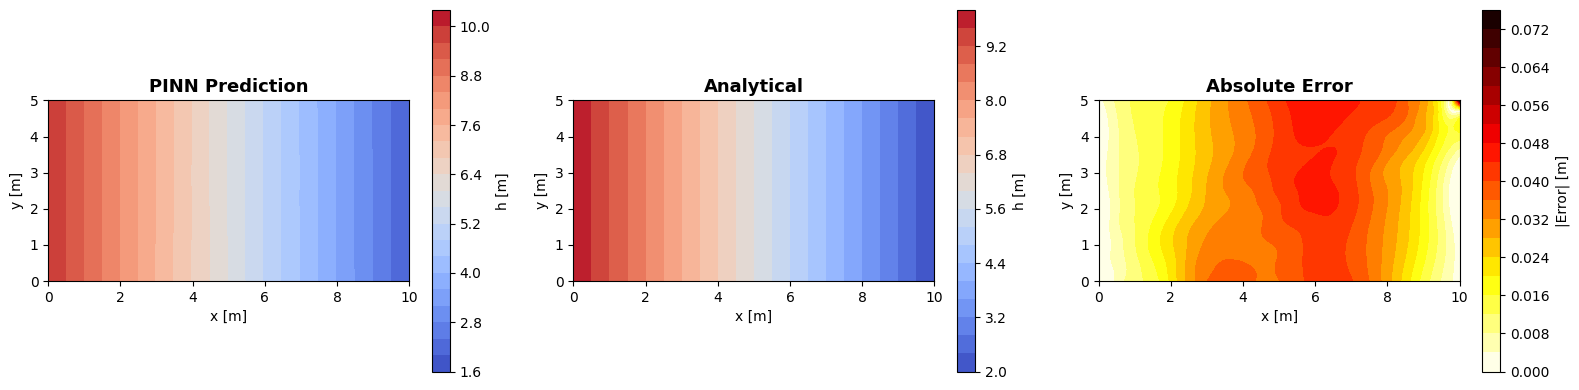

📊 L2 Relative Error: 4.74e-03
📊 Max Absolute Error: 7.38e-02 m


In [ ]:
# ── Predict & compare ────────────────────────────────────────────────
nx, ny = 100, 50
x_g = np.linspace(0, Lx, nx)
y_g = np.linspace(0, Ly, ny)
Xg, Yg = np.meshgrid(x_g, y_g)
pts = np.column_stack([Xg.flatten(), Yg.flatten()])

h_pred = model_seep.predict(pts).reshape(ny, nx)
h_true = analytical_seepage(pts).reshape(ny, nx)
h_err  = np.abs(h_pred - h_true)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cs1 = axes[0].contourf(Xg, Yg, h_pred, levels=20, cmap='coolwarm')
plt.colorbar(cs1, ax=axes[0], label='h [m]')
axes[0].set_title('PINN Prediction', fontsize=13, fontweight='bold')
axes[0].set_aspect('equal')

cs2 = axes[1].contourf(Xg, Yg, h_true, levels=20, cmap='coolwarm')
plt.colorbar(cs2, ax=axes[1], label='h [m]')
axes[1].set_title('Analytical', fontsize=13, fontweight='bold')
axes[1].set_aspect('equal')

cs3 = axes[2].contourf(Xg, Yg, h_err, levels=20, cmap='hot_r')
plt.colorbar(cs3, ax=axes[2], label='|Error| [m]')
axes[2].set_title('Absolute Error', fontsize=13, fontweight='bold')
axes[2].set_aspect('equal')

for ax in axes:
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
plt.tight_layout(); plt.show()

l2 = np.linalg.norm(h_pred - h_true) / np.linalg.norm(h_true)
print(f"📊 L2 Relative Error: {l2:.2e}")
print(f"📊 Max Absolute Error: {np.max(h_err):.2e} m")


### 1.5 🔍 Inverse Problem — Discover unknown K from piezometers

**Scenario**: You have a dam with unknown soil permeability. 8 piezometers give you head readings. Can the PINN discover K?

$$\mathcal{L} = \mathcal{L}_{PDE}(K) + \mathcal{L}_{BC} + \mathcal{L}_{data}^{piezometers}$$


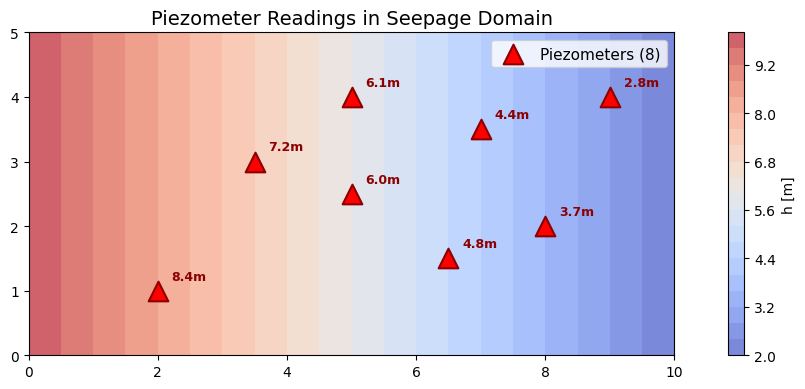

🎯 True K = 5.0 (we want the PINN to discover this!)


In [ ]:
# ── Synthetic piezometer data ────────────────────────────────────────
np.random.seed(42)
K_true_val = 5.0  # True K (unknown to us!)

x_piezo = np.array([
    [2.0, 1.0], [3.5, 3.0], [5.0, 2.5], [5.0, 4.0],
    [6.5, 1.5], [7.0, 3.5], [8.0, 2.0], [9.0, 4.0]
])
h_piezo = analytical_seepage(x_piezo) + 0.02 * np.std(analytical_seepage(x_piezo)) * np.random.randn(8, 1)

# Visualize piezometer locations
fig, ax = plt.subplots(figsize=(11, 4))
cs = ax.contourf(Xg, Yg, h_true, levels=20, cmap='coolwarm', alpha=0.7)
plt.colorbar(cs, label='h [m]')
ax.scatter(x_piezo[:, 0], x_piezo[:, 1], s=200, c='red', marker='^',
           zorder=5, label='Piezometers (8)', edgecolors='darkred', linewidths=1.5)
for i in range(8):
    ax.annotate(f'{h_piezo[i,0]:.1f}m', (x_piezo[i,0], x_piezo[i,1]),
                textcoords="offset points", xytext=(10, 8),
                fontsize=9, fontweight='bold', color='darkred')
ax.set_title('Piezometer Readings in Seepage Domain', fontsize=14)
ax.set_aspect('equal'); ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

print(f"🎯 True K = {K_true_val} (we want the PINN to discover this!)")


In [ ]:
# ── Inverse PINN: K is a trainable variable ──────────────────────────
K_var = dde.Variable(1.0)  # Wrong initial guess!

def laplace_inverse(x, h):
    dh_xx = dde.grad.hessian(h, x, i=0, j=0)
    dh_yy = dde.grad.hessian(h, x, i=1, j=1)
    return K_var * (dh_xx + dh_yy)

observe = dde.icbc.PointSetBC(x_piezo, h_piezo, component=0)
geom_inv = dde.geometry.Rectangle([0, 0], [Lx, Ly])

data_inv = dde.data.PDE(
    geom_inv, laplace_inverse,
    [bc_L, bc_R, bc_T, bc_B, observe],
    num_domain=1500, num_boundary=200, num_test=500,
    anchors=x_piezo,
)

net_inv = dde.nn.FNN([2, 40, 40, 40, 1], "tanh", "Glorot uniform")
model_inv = dde.Model(data_inv, net_inv)
variable_cb = dde.callbacks.VariableValue([K_var], period=1000, filename="K_history.dat")

print(f"Initial K guess: {float(K_var):.2f}  (true = {K_true_val})")
print("Training inverse PINN (Adam 10000)...")
model_inv.compile("adam", lr=1e-3, external_trainable_variables=[K_var])
_, _ = model_inv.train(iterations=10000, display_every=2500, callbacks=[variable_cb])

print("Fine-tuning with L-BFGS...")
model_inv.compile("L-BFGS", external_trainable_variables=[K_var])
_, _ = model_inv.train(callbacks=[variable_cb])

K_found = float(K_var)
print(f"{'='*50}")
print(f"🎯 True K:       {K_true_val}")
print(f"🧠 Discovered K: {K_found:.4f}")
print(f"📊 Error:        {abs(K_found - K_true_val)/K_true_val*100:.2f}%")
print(f"{'='*50}")


Initial K guess: 1.00  (true = 5.0)
Training inverse PINN (Adam 10000)...
Compiling model...
'compile' took 0.000235 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [2.93e-03, 1.07e+02, 5.15e+00, 1.32e-03, 1.66e-02, 3.53e+01]    [2.77e-03, 1.07e+02, 5.15e+00, 1.32e-03, 1.66e-02, 3.53e+01]    []  


/usr/local/lib/python3.12/dist-packages/torch/utils/_device.py:109: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return func(*args, **kwargs)


2500      [7.91e-04, 4.22e-05, 1.65e-04, 3.94e-03, 1.18e-04, 1.00e-03]    [3.00e-04, 4.22e-05, 1.65e-04, 3.94e-03, 1.18e-04, 1.00e-03]    []  
5000      [2.04e-04, 7.40e-06, 9.31e-05, 3.83e-03, 1.41e-05, 6.81e-04]    [1.29e-04, 7.40e-06, 9.31e-05, 3.83e-03, 1.41e-05, 6.81e-04]    []  
7500      [1.55e-04, 4.61e-06, 1.37e-04, 3.57e-03, 5.31e-06, 4.74e-04]    [1.21e-04, 4.61e-06, 1.37e-04, 3.57e-03, 5.31e-06, 4.74e-04]    []  
10000     [5.37e-05, 1.81e-04, 6.43e-03, 3.10e-03, 9.68e-06, 4.28e-03]    [4.75e-05, 1.81e-04, 6.43e-03, 3.10e-03, 9.68e-06, 4.28e-03]    []  

Best model at step 7500:
  train loss: 4.34e-03
  test loss: 4.31e-03
  test metric: []

'train' took 93.986877 s

Fine-tuning with L-BFGS...
Compiling model...
'compile' took 0.000255 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
10000     [5.37e-05, 1.81e-04, 6.43e-03, 3.10e-03, 9.68e-06, 4.28e-03]

### 💬 Discussion — Module 1

1. **Where else does Laplace's equation appear in civil engineering?**
   - Groundwater flow, heat conduction through walls, electrostatics in soil
2. **What if K varies spatially?** → PDE becomes ∇·(K(x,y)∇h) = 0
3. **Real application**: Piezometers in a dam → PINN discovers K → piping risk assessment

---


# 🏗️ Module 2 — Euler-Bernoulli Beam Deflection

**Department**: Structural Engineering

### The PDE:

$$EI \frac{d^4 v}{dx^4} = q(x)$$

**Cantilever beam** (fixed at x=0, free at x=L) under uniform load q:

| At x = 0 (Fixed) | At x = L (Free) |
|---|---|
| v(0) = 0 — no deflection | v″(L) = 0 — no moment |
| v′(0) = 0 — no slope | v‴(L) = 0 — no shear |

**Analytical**: $v(x) = \frac{q}{24EI}(x^4 - 4Lx^3 + 6L^2x^2)$

> 🔑 **Note**: This is a **4th-order** ODE — the highest-order PDE we solve today. PINN handles it just as easily!


### 2.1 Define beam parameters & PDE


In [ ]:
# ── Beam parameters ──────────────────────────────────────────────────
L_beam  = 1.0   # length [m]
EI_beam = 1.0   # flexural rigidity [N*m^2]
q_beam  = 1.0   # uniform load [N/m]

# Exact cantilever deflection: q/(24EI) * (x^4 - 4Lx^3 + 6L^2x^2)
def analytical_beam(x):
    return (q_beam / (24 * EI_beam)) * (x**4 - 4*L_beam*x**3 + 6*L_beam**2*x**2)

# ── PDE residual: EI * d4v/dx4 = q ──────────────────────────────────
def beam_pde(x, v):
    dv_xx   = dde.grad.hessian(v, x)        # d2v/dx2
    dv_xxxx = dde.grad.hessian(dv_xx, x)    # d4v/dx4
    return EI_beam * dv_xxxx - q_beam

# ── Geometry & BCs ───────────────────────────────────────────────────
geom_beam = dde.geometry.Interval(0, L_beam)

def bnd_fix(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0)
def bnd_free(x, on_boundary):
    return on_boundary and np.isclose(x[0], L_beam)

bc_v0  = dde.icbc.DirichletBC(geom_beam, lambda x: 0, bnd_fix)            # v(0) = 0
bc_dv0 = dde.icbc.NeumannBC(geom_beam, lambda x: 0, bnd_fix)             # v'(0) = 0
bc_M   = dde.icbc.OperatorBC(geom_beam,
           lambda x, v, _: dde.grad.hessian(v, x), bnd_free)              # v''(L) = 0
bc_V   = dde.icbc.OperatorBC(geom_beam,
           lambda x, v, _: dde.grad.jacobian(dde.grad.hessian(v, x), x),
           bnd_free)                                                        # v'''(L) = 0

print("✅ 4th-order beam PDE defined!")
print("   v(0)=0, v'(0)=0, v''(L)=0, v'''(L)=0")


✅ 4th-order beam PDE defined!
   v(0)=0, v'(0)=0, v''(L)=0, v'''(L)=0


### 2.2 Train & visualize


Training beam PINN (Adam 8000)...
Compiling model...
'compile' took 0.000149 s

Training model...

Step      Train loss                                            Test loss                                             Test metric   
0         [1.24e+00, 0.00e+00, 3.98e-02, 3.12e-03, 4.36e-05]    [1.24e+00, 0.00e+00, 3.98e-02, 3.12e-03, 4.36e-05]    [2.72e+00]    
2000      [4.41e-05, 4.94e-09, 3.94e-09, 3.48e-08, 8.19e-09]    [3.98e-05, 4.94e-09, 3.94e-09, 3.48e-08, 8.19e-09]    [1.00e-03]    
4000      [1.64e-06, 2.05e-07, 7.20e-06, 3.11e-07, 2.36e-09]    [1.53e-06, 2.05e-07, 7.20e-06, 3.11e-07, 2.36e-09]    [2.94e-02]    
6000      [4.35e-06, 2.08e-05, 1.64e-04, 3.59e-06, 2.99e-07]    [4.07e-06, 2.08e-05, 1.64e-04, 3.59e-06, 2.99e-07]    [5.94e-02]    
8000      [3.17e-06, 1.92e-06, 7.72e-07, 7.98e-08, 1.30e-08]    [2.81e-06, 1.92e-06, 7.72e-07, 7.98e-08, 1.30e-08]    [2.81e-02]    

Best model at step 8000:
  train loss: 5.96e-06
  test loss: 5.59e-06
  test metric: [2.81e-02]

'trai

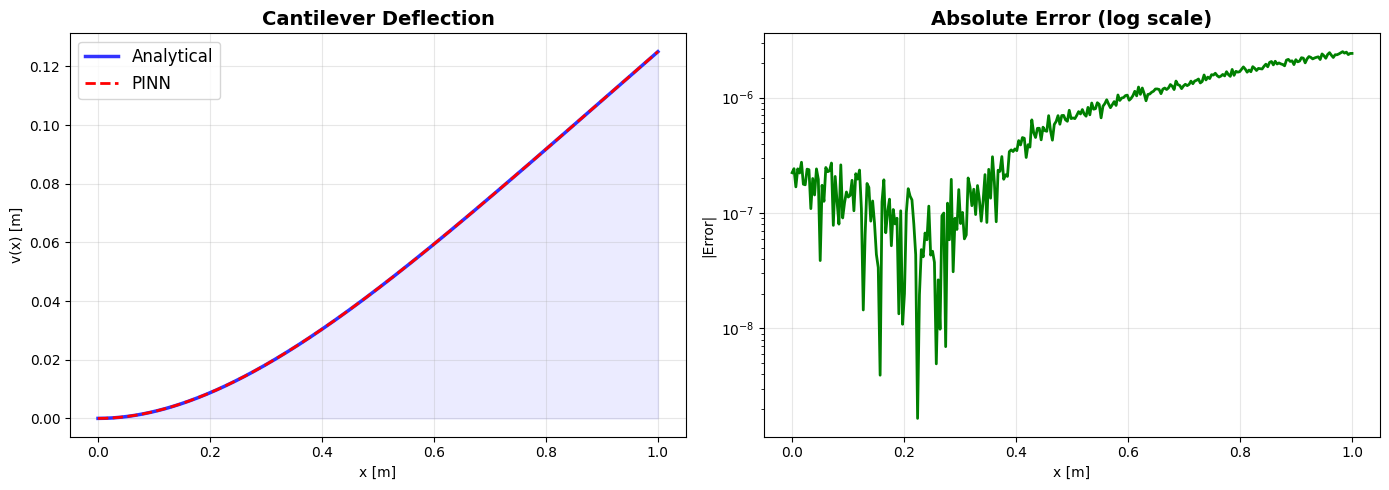

📊 L2 Relative Error: 1.84e-05
📊 Tip deflection: PINN = 0.125002, Exact = 0.125000


In [ ]:
# ── Train beam PINN ──────────────────────────────────────────────────
data_beam = dde.data.PDE(
    geom_beam, beam_pde,
    [bc_v0, bc_dv0, bc_M, bc_V],
    num_domain=100, num_boundary=2, num_test=200,
    solution=analytical_beam,
)

net_beam = dde.nn.FNN([1, 40, 40, 40, 40, 1], "tanh", "Glorot uniform")
model_beam = dde.Model(data_beam, net_beam)

print("Training beam PINN (Adam 8000)...")
model_beam.compile("adam", lr=1e-3, metrics=["l2 relative error"])
_, _ = model_beam.train(iterations=8000, display_every=2000)

print("L-BFGS fine-tuning...")
model_beam.compile("L-BFGS", metrics=["l2 relative error"])
_, _ = model_beam.train()

# ── Plot ─────────────────────────────────────────────────────────────
x_b = np.linspace(0, L_beam, 300).reshape(-1, 1)
v_pred = model_beam.predict(x_b)
v_true = analytical_beam(x_b)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x_b, v_true, 'b-', lw=2.5, label='Analytical', alpha=0.8)
axes[0].plot(x_b, v_pred, 'r--', lw=2, label='PINN')
axes[0].fill_between(x_b.flatten(), v_true.flatten(), alpha=0.08, color='blue')
axes[0].set_xlabel('x [m]'); axes[0].set_ylabel('v(x) [m]')
axes[0].set_title('Cantilever Deflection', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(x_b, np.abs(v_pred - v_true), 'g-', lw=2)
axes[1].set_xlabel('x [m]'); axes[1].set_ylabel('|Error|')
axes[1].set_title('Absolute Error (log scale)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

l2_beam = np.linalg.norm(v_pred - v_true) / np.linalg.norm(v_true)
print(f"📊 L2 Relative Error: {l2_beam:.2e}")
print(f"📊 Tip deflection: PINN = {v_pred[-1,0]:.6f}, Exact = {v_true[-1,0]:.6f}")


### 2.3 🔍 Inverse — Discover unknown stiffness EI from sensors


Initial EI guess: 0.50  (true = 1.0)
Training inverse beam PINN (Adam 10000)...
Compiling model...
'compile' took 0.000169 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [1.22e+00, 0.00e+00, 8.07e-03, 3.58e-03, 2.09e-03, 1.55e-02]    [1.22e+00, 0.00e+00, 8.07e-03, 3.58e-03, 2.09e-03, 1.55e-02]    []  
2500      [2.86e-05, 5.61e-05, 5.28e-05, 1.59e-05, 7.64e-06, 2.09e-04]    [2.36e-05, 5.61e-05, 5.28e-05, 1.59e-05, 7.64e-06, 2.09e-04]    []  
5000      [6.24e-05, 3.32e-06, 6.51e-06, 6.01e-06, 7.54e-06, 3.86e-05]    [5.91e-05, 3.32e-06, 6.51e-06, 6.01e-06, 7.54e-06, 3.86e-05]    []  
7500      [8.69e-06, 2.44e-08, 1.87e-07, 7.77e-07, 7.34e-09, 9.19e-06]    [7.52e-06, 2.44e-08, 1.87e-07, 7.77e-07, 7.34e-09, 9.19e-06]    []  
10000     [1.24e-05, 8.98e-07, 5.33e-07, 6.90e-08, 4.33e-07, 3.55e-06]    [1.06e-05, 8.98e-07, 5.33e-07, 6.90e-08, 4.33e-07, 3.55e-06

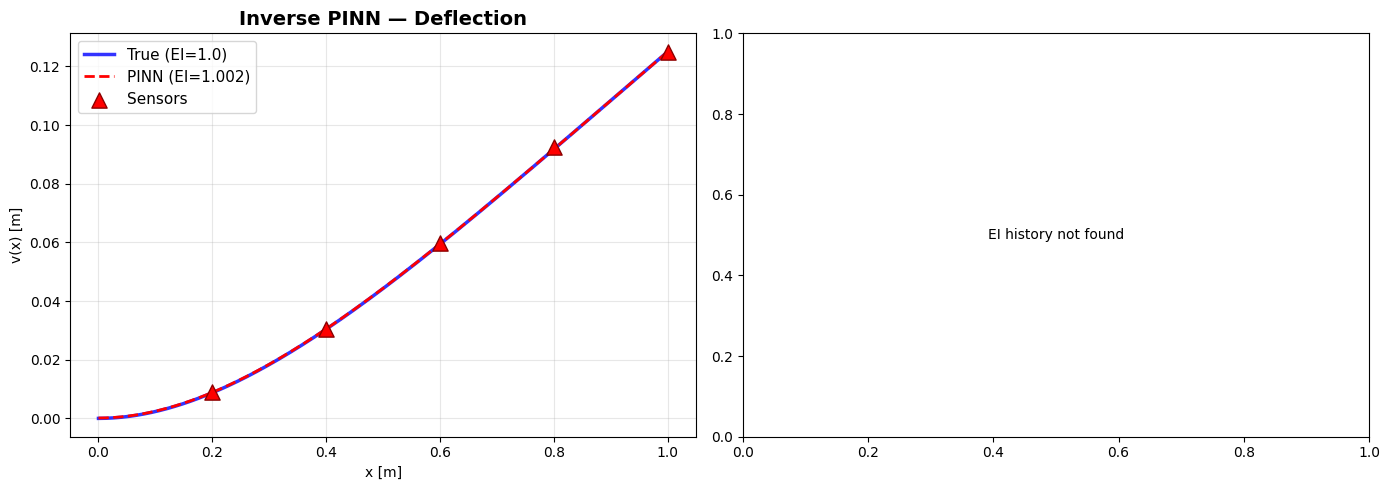

🏗️ Real application: Sensors on an aging bridge -> PINN discovers actual stiffness -> damage detection!


In [ ]:
# ── Synthetic sensor data ────────────────────────────────────────────
np.random.seed(42)
EI_true = 1.0
n_sensors = 5
x_sens = np.linspace(0.2, L_beam, n_sensors).reshape(-1, 1)
v_sens = analytical_beam(x_sens)
v_sens_noisy = v_sens + 0.01 * np.std(v_sens) * np.random.randn(*v_sens.shape)

# ── Inverse PINN ─────────────────────────────────────────────────────
EI_var = dde.Variable(0.5)  # Wrong initial guess

def beam_pde_inv(x, v):
    dv_xx   = dde.grad.hessian(v, x)
    dv_xxxx = dde.grad.hessian(dv_xx, x)
    return EI_var * dv_xxxx - q_beam

observe_beam = dde.icbc.PointSetBC(x_sens, v_sens_noisy, component=0)

data_beam_inv = dde.data.PDE(
    dde.geometry.Interval(0, L_beam), beam_pde_inv,
    [bc_v0, bc_dv0, bc_M, bc_V, observe_beam],
    num_domain=100, num_boundary=2, num_test=200,
    anchors=x_sens,
)

net_beam_inv = dde.nn.FNN([1, 40, 40, 40, 40, 1], "tanh", "Glorot uniform")
model_beam_inv = dde.Model(data_beam_inv, net_beam_inv)
ei_cb = dde.callbacks.VariableValue([EI_var], period=1000, filename="EI_history.dat")

print(f"Initial EI guess: {float(EI_var):.2f}  (true = {EI_true})")
print("Training inverse beam PINN (Adam 10000)...")
model_beam_inv.compile("adam", lr=1e-3, external_trainable_variables=[EI_var])
_, _ = model_beam_inv.train(iterations=10000, display_every=2500, callbacks=[ei_cb])

print("L-BFGS fine-tuning...")
model_beam_inv.compile("L-BFGS", external_trainable_variables=[EI_var])
_, _ = model_beam_inv.train(callbacks=[ei_cb])

EI_found = float(EI_var)
print(f"{'='*50}")
print(f"🎯 True EI:       {EI_true}")
print(f"🧠 Discovered EI: {EI_found:.4f}")
print(f"📊 Error:         {abs(EI_found - EI_true)/EI_true*100:.2f}%")
print(f"{'='*50}")

# ── Convergence plot ─────────────────────────────────────────────────
v_inv = model_beam_inv.predict(x_b)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_b, v_true, 'b-', lw=2.5, label='True (EI=1.0)', alpha=0.8)
axes[0].plot(x_b, v_inv, 'r--', lw=2, label=f'PINN (EI={EI_found:.3f})')
axes[0].scatter(x_sens, v_sens_noisy, s=120, c='red', marker='^',
                zorder=5, label='Sensors', edgecolors='darkred')
axes[0].set_title('Inverse PINN — Deflection', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('x [m]'); axes[0].set_ylabel('v(x) [m]')

try:
    ei_data = np.loadtxt("EI_history.dat", comments="#")
    if ei_data.ndim == 1: ei_data = ei_data.reshape(1, -1)
    axes[1].plot(ei_data[:, 0], ei_data[:, 1], 'purple', lw=2)
    axes[1].axhline(y=EI_true, color='green', ls='--', lw=2, label=f'True EI = {EI_true}')
    axes[1].set_xlabel('Step'); axes[1].set_ylabel('EI')
    axes[1].set_title('EI Convergence', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=12); axes[1].grid(True, alpha=0.3)
except:
    axes[1].text(0.5, 0.5, 'EI history not found', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout(); plt.show()
print("🏗️ Real application: Sensors on an aging bridge -> PINN discovers actual stiffness -> damage detection!")


### 💬 Discussion — Module 2

1. **Structural Health Monitoring (SHM)**: sensors on bridges → PINN discovers stiffness → damage detection without a full FEM model
2. **What if EI varies along the beam?** → damage localization: EI(x) drops where cracks form
3. **Extension**: 2D plate bending → ∇⁴w = q/D (Kirchhoff plate theory)

---


# 🚛 Module 3 — Pollutant Transport (Advection-Diffusion)

**Departments**: Transport · Environmental · Water Resources

### The PDE:

$$\frac{\partial c}{\partial t} + u \frac{\partial c}{\partial x} = D \frac{\partial^2 c}{\partial x^2}$$

| Symbol | Meaning | Value |
|--------|---------|-------|
| c(x,t) | Pollutant concentration | — |
| u | Flow velocity | 1.0 m/s |
| D | Diffusion coefficient | 0.1 m²/s |

**Initial condition**: Gaussian pulse — a chemical spill at x₀

**What happens**: The pulse moves downstream (advection) and spreads out (diffusion)

> 🌍 **Applications**: River pollution, groundwater contamination, smoke dispersion, sediment transport

> 🔑 **New**: This is our first **time-dependent** PINN! The network now takes (x, t) as input.


### 3.1 Define problem & analytical solution


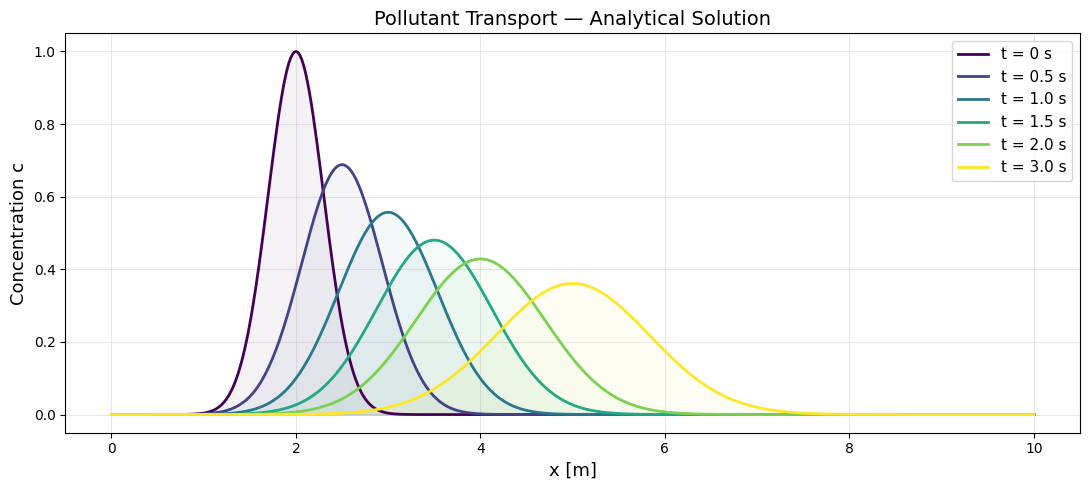

🌊 The plume moves downstream (advection) AND spreads out (diffusion)
   Peclet number: Pe = uL/D = 100  (advection-dominated)


In [ ]:
# ── Transport parameters ─────────────────────────────────────────────
u_vel = 1.0     # advection velocity [m/s]
D_coeff = 0.1   # diffusion coefficient [m^2/s]
x0_pulse = 2.0  # initial pulse location [m]
sigma0 = 0.3    # initial pulse width [m]
x_min, x_max = 0.0, 10.0
t_max = 3.0

# Analytical: Gaussian spreading + advection
def analytical_advdiff(x, t):
    sigma_t = np.sqrt(sigma0**2 + 2 * D_coeff * t)
    return (sigma0 / sigma_t) * np.exp(-((x - x0_pulse - u_vel * t)**2) / (2 * sigma_t**2))

# Visualize at different times
fig, ax = plt.subplots(figsize=(11, 5))
x_vis = np.linspace(x_min, x_max, 500)
colors = plt.cm.viridis(np.linspace(0, 1, 6))

for i, t_val in enumerate([0, 0.5, 1.0, 1.5, 2.0, 3.0]):
    c_vals = analytical_advdiff(x_vis, t_val)
    ax.plot(x_vis, c_vals, color=colors[i], lw=2, label=f't = {t_val} s')
    ax.fill_between(x_vis, c_vals, alpha=0.05, color=colors[i])

ax.set_xlabel('x [m]', fontsize=13)
ax.set_ylabel('Concentration c', fontsize=13)
ax.set_title('Pollutant Transport — Analytical Solution', fontsize=14)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("🌊 The plume moves downstream (advection) AND spreads out (diffusion)")
print(f"   Peclet number: Pe = uL/D = {u_vel * (x_max-x_min) / D_coeff:.0f}  (advection-dominated)")


### 3.2 Train the time-dependent PINN

> 🔑 Now our neural network takes **(x, t)** as input → outputs **c(x, t)**


In [ ]:
# ── PDE residual: dc/dt + u*dc/dx - D*d2c/dx2 = 0 ──────────────────
def advdiff_pde(x, c):
    dc_t  = dde.grad.jacobian(c, x, i=0, j=1)   # dc/dt
    dc_x  = dde.grad.jacobian(c, x, i=0, j=0)   # dc/dx
    dc_xx = dde.grad.hessian(c, x, i=0, j=0)    # d2c/dx2
    return dc_t + u_vel * dc_x - D_coeff * dc_xx

# ── Space-time domain ────────────────────────────────────────────────
geom_x = dde.geometry.Interval(x_min, x_max)
timedomain = dde.geometry.TimeDomain(0, t_max)
geomtime = dde.geometry.GeometryXTime(geom_x, timedomain)

# ── Initial condition: Gaussian pulse ────────────────────────────────
def ic_func(x):
    return np.exp(-((x[:, 0:1] - x0_pulse)**2) / (2 * sigma0**2))

ic = dde.icbc.IC(geomtime, ic_func, lambda _, on_initial: on_initial)

# ── Boundary conditions: c -> 0 at both ends ────────────────────────
bc_left_ad  = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda x, on_bnd: on_bnd and np.isclose(x[0], x_min))
bc_right_ad = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda x, on_bnd: on_bnd and np.isclose(x[0], x_max))

print("✅ Time-dependent PDE defined!")
print(f"   Domain: x in [{x_min}, {x_max}], t in [0, {t_max}]")
print(f"   IC: Gaussian pulse at x = {x0_pulse}")


✅ Time-dependent PDE defined!
   Domain: x in [0.0, 10.0], t in [0, 3.0]
   IC: Gaussian pulse at x = 2.0


In [ ]:
# ── Train ─────────────────────────────────────────────────────────────
data_ad = dde.data.TimePDE(
    geomtime, advdiff_pde,
    [ic, bc_left_ad, bc_right_ad],
    num_domain=3000, num_boundary=300, num_initial=300, num_test=1000,
)

net_ad = dde.nn.FNN([2, 40, 40, 40, 1], "tanh", "Glorot uniform")
model_ad = dde.Model(data_ad, net_ad)

print("Training advection-diffusion PINN (Adam 8000)...")
model_ad.compile("adam", lr=1e-3)
_, _ = model_ad.train(iterations=8000, display_every=2000)

print("L-BFGS fine-tuning...")
model_ad.compile("L-BFGS")
_, _ = model_ad.train()
print("✅ Transport PINN trained!")


Training advection-diffusion PINN (Adam 8000)...
Compiling model...
'compile' took 0.000129 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [2.75e-03, 8.28e-02, 6.65e-03, 2.52e-02]    [3.16e-03, 8.28e-02, 6.65e-03, 2.52e-02]    []  
2000      [1.10e-04, 6.58e-05, 2.29e-05, 4.31e-05]    [6.91e-05, 6.58e-05, 2.29e-05, 4.31e-05]    []  
4000      [1.78e-05, 3.47e-06, 2.47e-07, 1.89e-07]    [1.56e-05, 3.47e-06, 2.47e-07, 1.89e-07]    []  
6000      [5.73e-06, 1.40e-06, 1.88e-07, 2.87e-08]    [5.06e-06, 1.40e-06, 1.88e-07, 2.87e-08]    []  
8000      [2.87e-06, 9.96e-07, 1.01e-07, 1.20e-07]    [2.36e-06, 9.96e-07, 1.01e-07, 1.20e-07]    []  

Best model at step 8000:
  train loss: 4.09e-06
  test loss: 3.57e-06
  test metric: []

'train' took 54.895810 s

L-BFGS fine-tuning...
Compiling model...
'compile' took 0.000250 s

Training model...

Step      Train loss                                  Test

### 3.3 Results — watch the plume move!


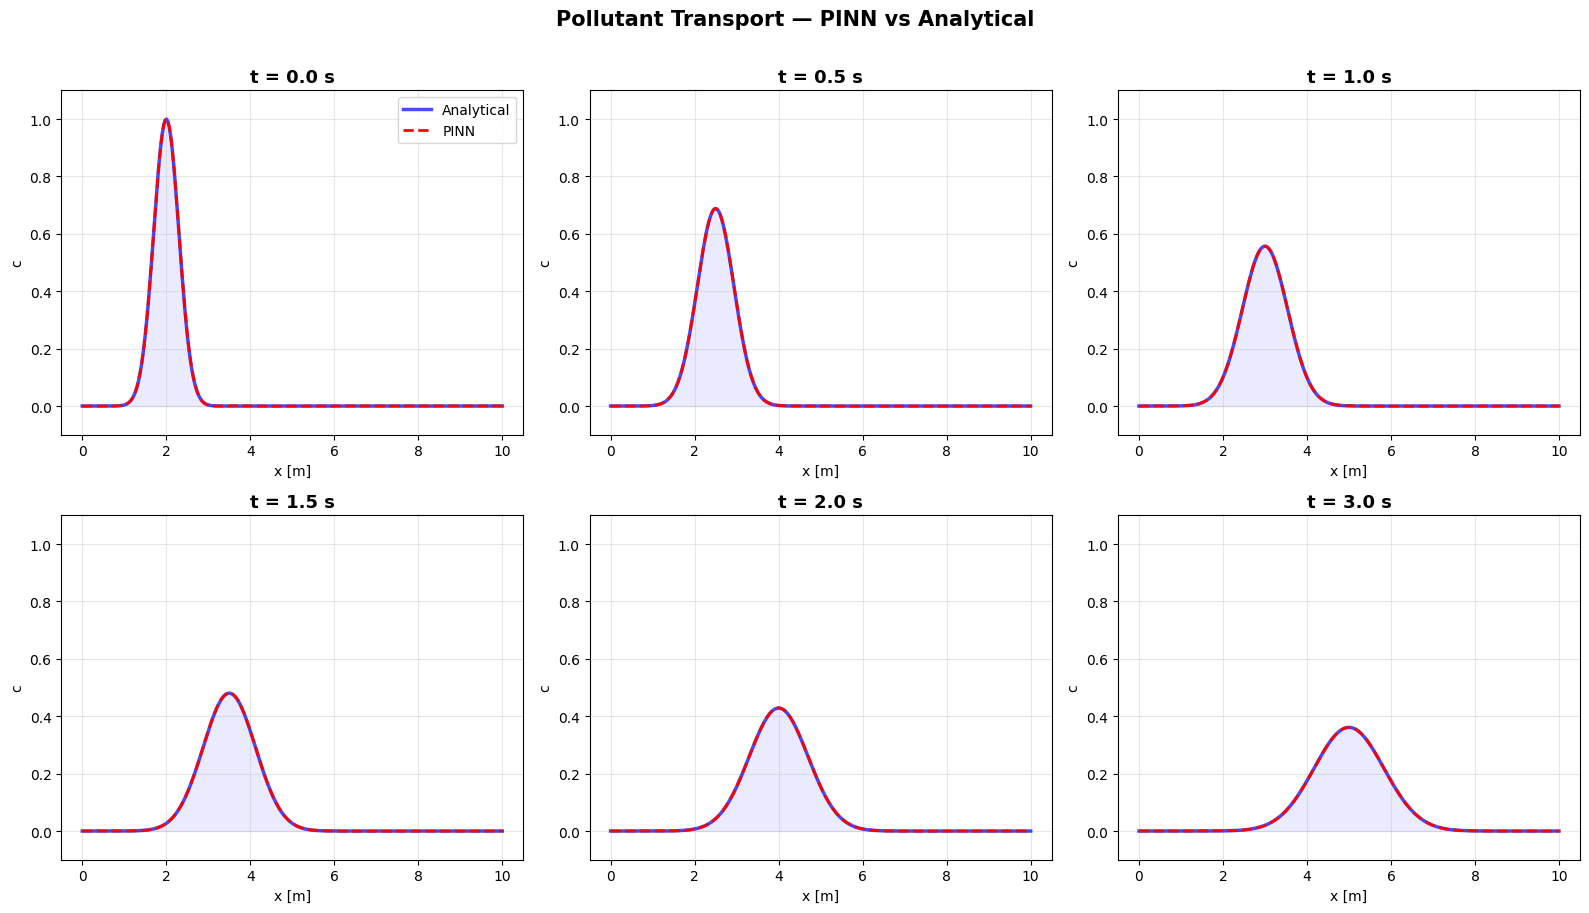

📊 Overall L2 Relative Error: 1.36e-03


In [ ]:
# ── Compare PINN vs analytical at multiple times ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
x_test_ad = np.linspace(x_min, x_max, 300)
times = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]

for idx, (ax, t_val) in enumerate(zip(axes.flat, times)):
    xt = np.column_stack([x_test_ad, np.full_like(x_test_ad, t_val)])
    c_pinn = model_ad.predict(xt)
    c_exact = analytical_advdiff(x_test_ad, t_val).reshape(-1, 1)

    ax.plot(x_test_ad, c_exact, 'b-', lw=2.5, label='Analytical', alpha=0.7)
    ax.plot(x_test_ad, c_pinn, 'r--', lw=2, label='PINN')
    ax.fill_between(x_test_ad, c_exact.flatten(), alpha=0.08, color='blue')
    ax.set_title(f't = {t_val} s', fontsize=13, fontweight='bold')
    ax.set_xlabel('x [m]'); ax.set_ylabel('c')
    ax.set_ylim(-0.1, 1.1); ax.grid(True, alpha=0.3)
    if idx == 0: ax.legend(fontsize=10)

plt.suptitle('Pollutant Transport — PINN vs Analytical', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

# Overall error
xt_all = np.column_stack([np.tile(x_test_ad, len(times)), np.repeat(times, len(x_test_ad))])
c_pred_all = model_ad.predict(xt_all)
c_true_all = analytical_advdiff(xt_all[:, 0], xt_all[:, 1]).reshape(-1, 1)
l2_ad = np.linalg.norm(c_pred_all - c_true_all) / (np.linalg.norm(c_true_all) + 1e-10)
print(f"📊 Overall L2 Relative Error: {l2_ad:.2e}")


### 💬 Discussion — Module 3

1. **Transport Engineering**: traffic flow models use similar equations (Lighthill-Whitham-Richards)
2. **Groundwater contamination**: same PDE in 2D → contaminant plume prediction
3. **Climate & hydrology**: sediment transport, thermal diffusion in dam bodies
4. **Key insight**: PINN handled the **time dimension** seamlessly — (x,t) input, c(x,t) output

---


# 🌀 Module 4 — Burgers' Equation (= Simplified Navier-Stokes!)

**Department**: Hydraulics · Fluid Mechanics

### The connection to Navier-Stokes:

The **Navier-Stokes momentum equation** (1D, incompressible):

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = -\frac{1}{\rho}\frac{\partial p}{\partial x} + \nu \frac{\partial^2 u}{\partial x^2}$$

Drop the pressure gradient → you get **Burgers' equation**:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$

| Term | Physics |
|------|---------|
| ∂u/∂t | Temporal change |
| u · ∂u/∂x | **Nonlinear convection** (inertia — what makes fluids interesting!) |
| ν · ∂²u/∂x² | Viscous diffusion |

> 🔑 **Why this matters**: Burgers' equation captures the essence of fluid dynamics — the competition between nonlinear steepening and viscous smoothing. It produces **shock waves**, similar to hydraulic jumps in open channel flow!

> 📜 This is the **exact problem** from Raissi's 2019 paper that started the PINN revolution.


### 4.1 Setup: the classic Raissi benchmark


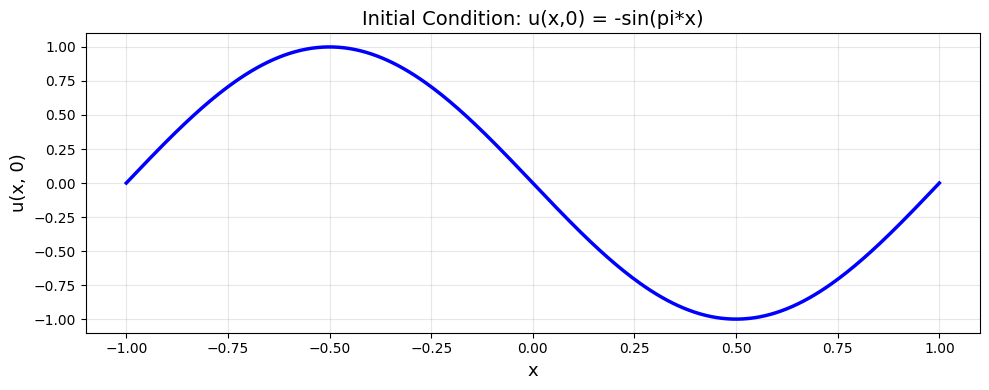

Viscosity nu = 0.00318
Reynolds-like number: 1/(pi*nu) = 100  -> sharp shock will form!


In [ ]:
# ── Burgers parameters ──────────────────────────────────────────────
nu = 0.01 / np.pi   # Viscosity (small -> sharp shock)
x_lo, x_hi = -1.0, 1.0
t_end = 1.0

# Visualize IC
x_vis_b = np.linspace(x_lo, x_hi, 300)
plt.figure(figsize=(10, 4))
plt.plot(x_vis_b, -np.sin(np.pi * x_vis_b), 'b-', lw=2.5)
plt.xlabel('x', fontsize=13); plt.ylabel('u(x, 0)', fontsize=13)
plt.title('Initial Condition: u(x,0) = -sin(pi*x)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Viscosity nu = {nu:.5f}")
print(f"Reynolds-like number: 1/(pi*nu) = {1/(np.pi*nu):.0f}  -> sharp shock will form!")


### 4.2 Train the Burgers' PINN


In [ ]:
# ── PDE residual: du/dt + u*du/dx - nu*d2u/dx2 = 0 ─────────────────
def burgers_pde(x, u):
    du_t  = dde.grad.jacobian(u, x, i=0, j=1)
    du_x  = dde.grad.jacobian(u, x, i=0, j=0)
    du_xx = dde.grad.hessian(u, x, i=0, j=0)
    return du_t + u * du_x - nu * du_xx

# ── Space-time domain ────────────────────────────────────────────────
geom_b = dde.geometry.Interval(x_lo, x_hi)
time_b = dde.geometry.TimeDomain(0, t_end)
geomtime_b = dde.geometry.GeometryXTime(geom_b, time_b)

# ── IC: u(x,0) = -sin(pi*x) ─────────────────────────────────────────
ic_b = dde.icbc.IC(geomtime_b,
                    lambda x: -np.sin(np.pi * x[:, 0:1]),
                    lambda _, on_initial: on_initial)

# ── BCs: u(-1,t) = u(1,t) = 0 ───────────────────────────────────────
bc_b = dde.icbc.DirichletBC(geomtime_b, lambda x: 0,
                             lambda x, on_bnd: on_bnd)

print("✅ Burgers equation defined!")
print(f"   Domain: x in [{x_lo}, {x_hi}], t in [0, {t_end}]")
print("   IC: u(x,0) = -sin(pi*x)")
print("   BC: u(+/-1,t) = 0")


✅ Burgers equation defined!
   Domain: x in [-1.0, 1.0], t in [0, 1.0]
   IC: u(x,0) = -sin(pi*x)
   BC: u(+/-1,t) = 0


In [ ]:
# ── Train ─────────────────────────────────────────────────────────────
data_b = dde.data.TimePDE(
    geomtime_b, burgers_pde,
    [bc_b, ic_b],
    num_domain=4000, num_boundary=200, num_initial=300, num_test=1000,
)

net_b = dde.nn.FNN([2, 40, 40, 40, 40, 1], "tanh", "Glorot uniform")
model_b = dde.Model(data_b, net_b)

print("Training Burgers PINN (Adam 10000)...")
model_b.compile("adam", lr=1e-3)
_, _ = model_b.train(iterations=10000, display_every=2500)

print("L-BFGS fine-tuning...")
model_b.compile("L-BFGS")
_, _ = model_b.train()
print("✅ Burgers PINN trained!")


Training Burgers PINN (Adam 10000)...
Compiling model...
'compile' took 0.000158 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [1.82e-01, 5.37e-02, 5.80e-01]    [1.82e-01, 5.37e-02, 5.80e-01]    []  
2500      [7.02e-03, 5.93e-05, 5.37e-03]    [1.12e-02, 5.93e-05, 5.37e-03]    []  
5000      [1.32e-03, 5.10e-06, 8.70e-04]    [2.04e-03, 5.10e-06, 8.70e-04]    []  
7500      [6.20e-04, 2.21e-06, 3.35e-04]    [1.01e-03, 2.21e-06, 3.35e-04]    []  
10000     [1.65e-03, 2.14e-05, 3.38e-04]    [5.03e-03, 2.14e-05, 3.38e-04]    []  

Best model at step 7500:
  train loss: 9.57e-04
  test loss: 1.35e-03
  test metric: []

'train' took 76.268259 s

L-BFGS fine-tuning...
Compiling model...
'compile' took 0.000305 s

Training model...

Step      Train loss                        Test loss                         Test metric
10000     [1.65e-03, 2.14e-05, 3.38e-04]    [5.03e-03, 2.14e-05, 3.38e-04]    []  
11000     [3.55e

### 4.3 Results — watch the shock form! 🌊


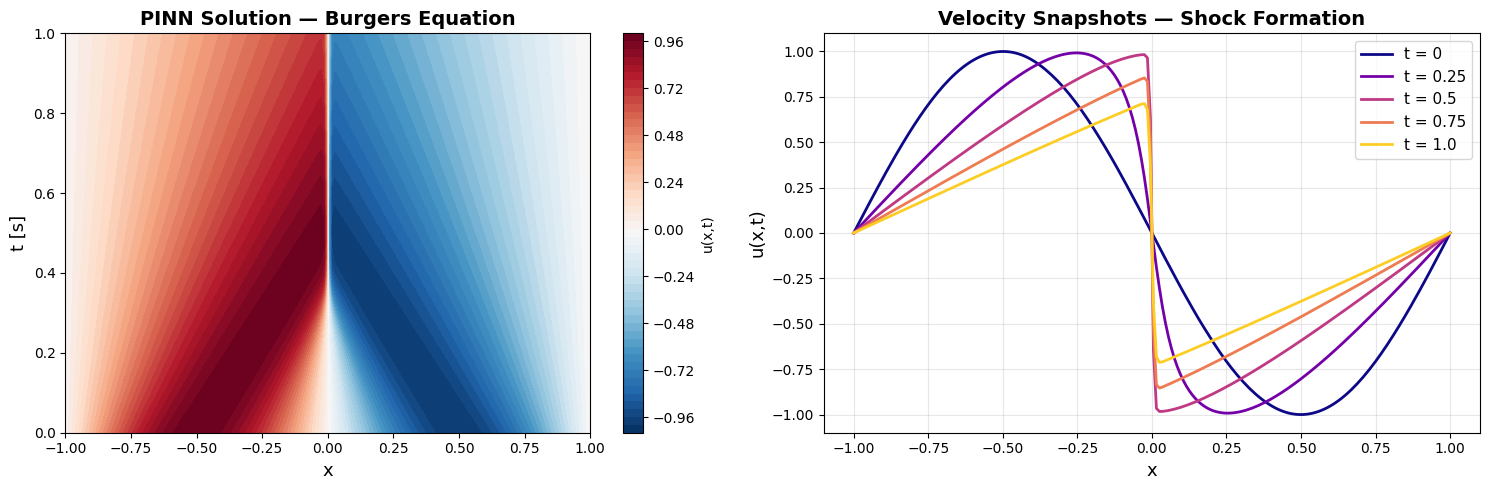

🌀 The nonlinear term u*du/dx steepens the wave -> SHOCK WAVE!
   This is the same physics behind hydraulic jumps in open channels.
   PINNs can capture this without special shock-capturing schemes!


In [ ]:
# ── Space-time contour plot ──────────────────────────────────────────
nx_b, nt_b = 200, 100
x_grid_b = np.linspace(x_lo, x_hi, nx_b)
t_grid_b = np.linspace(0, t_end, nt_b)
Xb, Tb = np.meshgrid(x_grid_b, t_grid_b)
xt_flat = np.column_stack([Xb.flatten(), Tb.flatten()])

u_pred_b = model_b.predict(xt_flat).reshape(nt_b, nx_b)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cs = axes[0].contourf(Xb, Tb, u_pred_b, levels=50, cmap='RdBu_r')
plt.colorbar(cs, ax=axes[0], label='u(x,t)')
axes[0].set_xlabel('x', fontsize=13); axes[0].set_ylabel('t [s]', fontsize=13)
axes[0].set_title("PINN Solution — Burgers Equation", fontsize=14, fontweight='bold')

times_snap = [0, 0.25, 0.5, 0.75, 1.0]
colors_b = plt.cm.plasma(np.linspace(0, 0.9, len(times_snap)))
for t_val, col in zip(times_snap, colors_b):
    xt_snap = np.column_stack([x_grid_b, np.full_like(x_grid_b, t_val)])
    u_snap = model_b.predict(xt_snap)
    axes[1].plot(x_grid_b, u_snap, color=col, lw=2, label=f't = {t_val}')

axes[1].set_xlabel('x', fontsize=13); axes[1].set_ylabel('u(x,t)', fontsize=13)
axes[1].set_title('Velocity Snapshots — Shock Formation', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("🌀 The nonlinear term u*du/dx steepens the wave -> SHOCK WAVE!")
print("   This is the same physics behind hydraulic jumps in open channels.")
print("   PINNs can capture this without special shock-capturing schemes!")


### 💬 Discussion — Module 4

1. **Hydraulic jumps**: The shock in Burgers' equation is analogous to a hydraulic jump in open channel flow
2. **Full Navier-Stokes**: Add pressure → 2D/3D → CFD with PINNs
3. **Turbulence**: Low viscosity → Reynolds-averaged N-S with PINNs (active research!)
4. **Applications**: Pipe flow, dam spillway design, wind loads on structures

---


# 🎓 What We Accomplished Today

| ✅ | PDE | Method | Department |
|---|-----|--------|------------|
| 🌊 | ∇²h = 0 (Laplace) | Forward + **Inverse** (discovered K) | Geotech · Water Resources |
| 🏗️ | EI·d⁴v/dx⁴ = q (Beam) | Forward + **Inverse** (discovered EI) | Structural |
| 🚛 | ∂c/∂t + u·∂c/∂x = D·∂²c/∂x² | Forward (time-dependent!) | Transport · Environmental |
| 🌀 | ∂u/∂t + u·∂u/∂x = ν·∂²u/∂x² | Forward (N-S in 1D → shock!) | Hydraulics |

### The PINN pattern — always the same:

```
📐 Your PDE (the physics you know)
    +
🎯 Boundary / Initial conditions
    +
🧠 Neural network + automatic differentiation
    =
💡 Solution — no mesh, no flow nets, no manual discretization!
```


## 🚀 MTech Project Ideas — Pick Your Department!

| Department | PINN Project Idea | Key PDE |
|------------|-------------------|---------|
| **Structural** | Bridge damage detection from sensor data | EI(x)·v⁗ = q → discover EI(x) |
| **Geotechnical** | Heterogeneous soil K(x,y) from piezometers | ∇·(K∇h) = 0, inverse |
| **Water Resources** | Flood routing with unknown Manning's n | Saint-Venant equations + PINN |
| **Hydraulics** | 2D flow past bridge pier (Navier-Stokes) | Full N-S with obstacle geometry |
| **Transport** | Traffic density estimation from sparse sensors | LWR traffic flow PDE |
| **Environmental** | Groundwater contamination source identification | Advection-diffusion, inverse for source |

### What makes PINNs special for civil engineering:

1. **Sparse data** — civil sensors are expensive; PINNs work with few observations
2. **Inverse problems** — discover unknown material properties (K, EI, ν)
3. **No meshing** — especially valuable for complex geometries
4. **Physics-constrained** — predictions always respect conservation laws


## 📚 Key References

1. **Raissi, Perdikaris & Karniadakis** (2019). *Physics-informed neural networks.* Journal of Computational Physics.
2. **Lu et al.** (2021). *DeepXDE: A deep learning library for solving differential equations.* SIAM Review.
3. **Gao et al.** (2023). *PINN for phreatic line estimation in rectangular dam.* — Seepage
4. **Haghighat et al.** (2021). *Physics-informed deep learning for computational elastodynamics.* CMAME.
5. **He et al.** (2020). *PINNs for multiphysics data assimilation.* — Inverse problems

### 🔗 Resources:
- **DeepXDE documentation**: https://deepxde.readthedocs.io/
- **DeepXDE examples**: https://github.com/lululxvi/deepxde/tree/master/examples
- **PINN review paper**: Karniadakis et al. (2021), Nature Reviews Physics

---
*Built for the "AI for Civil Engineering" MTech Guest Lecture*
